## 1. Importaciones y carga

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from ydata_profiling import ProfileReport
import requests

In [3]:
caract = pd.read_csv('../data/clean/pre_clean/caracteristicas_edificios.csv')
consumo = pd.read_csv('../data/clean/pre_clean/consumos_energeticos.csv')

In [4]:
caract.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1199022 entries, 0 to 1199021
Data columns (total 16 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   id_edificio         1199022 non-null  int64  
 1   municipio           1198891 non-null  object 
 2   provincia           1199016 non-null  object 
 3   zona_climatica      1199021 non-null  object 
 4   ano_construccion    1192095 non-null  float64
 5   normativa           1195429 non-null  object 
 6   tipo_edificio       1199021 non-null  object 
 7   superficie          1199022 non-null  float64
 8   compacidad          1199022 non-null  float64
 9   pct_calefactado     1199022 non-null  int64  
 10  pct_refrigerado     1199022 non-null  int64  
 11  ventana_norte       1199022 non-null  float64
 12  ventana_sur         1199022 non-null  float64
 13  ventana_este        1199022 non-null  float64
 14  ventana_oeste       1199022 non-null  float64
 15  tipo_generador_

In [5]:
consumo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1199022 entries, 0 to 1199021
Data columns (total 2 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   id_edificio     1199022 non-null  int64  
 1   consumo_global  1199022 non-null  float64
dtypes: float64(1), int64(1)
memory usage: 18.3 MB


In [6]:
merge = pd.merge(caract, consumo, on='id_edificio')

In [7]:
df = merge
df.to_csv('../data/clean/df_regression.csv', index=False)

## 2. Primer análisis y correccion de tipos

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1199022 entries, 0 to 1199021
Data columns (total 17 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   id_edificio         1199022 non-null  int64  
 1   municipio           1198891 non-null  object 
 2   provincia           1199016 non-null  object 
 3   zona_climatica      1199021 non-null  object 
 4   ano_construccion    1192095 non-null  float64
 5   normativa           1195429 non-null  object 
 6   tipo_edificio       1199021 non-null  object 
 7   superficie          1199022 non-null  float64
 8   compacidad          1199022 non-null  float64
 9   pct_calefactado     1199022 non-null  int64  
 10  pct_refrigerado     1199022 non-null  int64  
 11  ventana_norte       1199022 non-null  float64
 12  ventana_sur         1199022 non-null  float64
 13  ventana_este        1199022 non-null  float64
 14  ventana_oeste       1199022 non-null  float64
 15  tipo_generador_

In [9]:
df.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
id_edificio,1199022.0,599510.50,3.461280e+05,0.00,299755.25,599510.50,899265.75,1.199021e+06
ano_construccion,1192095.0,1987.31,2.204000e+01,1718.00,1974.00,1991.00,2005.00,2.025000e+03
superficie,1199022.0,167.62,9.706300e+02,0.00,67.53,90.00,126.00,3.860496e+05
compacidad,1199022.0,5090.17,7.132478e+05,0.00,1.23,1.68,3.38,1.000000e+08
pct_calefactado,1199022.0,45.10,4.196000e+01,0.00,0.00,39.00,100.00,6.550000e+02
pct_refrigerado,1199022.0,41.40,4.086000e+01,0.00,0.00,31.00,86.00,6.550000e+02
ventana_norte,1199022.0,20.42,1.977000e+01,0.00,4.00,18.00,29.00,3.000000e+02
ventana_sur,1199022.0,23.59,2.215000e+01,0.00,7.00,20.00,33.00,3.000000e+02
ventana_este,1199022.0,7.39,1.359000e+01,0.00,0.00,0.00,12.00,1.000000e+02
ventana_oeste,1199022.0,7.07,1.333000e+01,0.00,0.00,0.00,11.00,1.000000e+02


In [10]:
df.select_dtypes(exclude=[np.number]).describe().round(2).T

,count,unique,top,freq
municipio,1198891,13055,Sevilla,91267
provincia,1199016,117,Málaga,308386
zona_climatica,1199021,14,A3,351965
normativa,1195429,2148,NBE-CT-79,591605
tipo_edificio,1199021,5,ViviendaIndividualEnBloque,588062
tipo_generador_cal,761949,95,Bomba de Calor,454760


NOTAS:

Superficies y compacidades de 0.00.....revisar. Missings no declarados?

Compacidad....9999999. Missings no declarados

Grandes asimetrías, sobretodo en compacidad

In [11]:
df.head()

,id_edificio,municipio,provincia,zona_climatica,ano_construccion,normativa,tipo_edificio,superficie,compacidad,pct_calefactado,pct_refrigerado,ventana_norte,ventana_sur,ventana_este,ventana_oeste,tipo_generador_cal,consumo_global
0,0,El Ejido,Almería,A4,1979.0,Anterior,ViviendaIndividualEnBloque,37.07,2.46,56,56,44.0,21.0,0.0,0.0,Bomba de Calor,112.36
1,1,El Ejido,Almería,A4,1992.0,NBE-CT-79,ViviendaIndividualEnBloque,123.58,1.43,0,0,38.0,38.0,0.0,0.0,NaN,176.72
2,2,El Ejido,Almería,A4,2003.0,NBE-CT-79,LocalUsoTerciario,104.25,1.79,87,87,33.0,0.0,37.0,0.0,Bomba de Calor,112.60
3,3,El Ejido,Almería,A4,1975.0,Anterior,ViviendaIndividualEnBloque,83.40,2.34,0,0,12.0,30.0,47.0,17.0,NaN,138.35
4,4,Almería,Almería,A4,2006.0,NBE-CT-79,ViviendaIndividualEnBloque,82.85,3.94,100,100,12.0,14.0,0.0,0.0,Bomba de calor tipo split/multisplit,96.69


In [12]:
to_factor = list(df.select_dtypes(exclude=[np.number]).columns)

In [13]:
df[to_factor] = df[to_factor].astype('category')

## 3. Corrección de errores

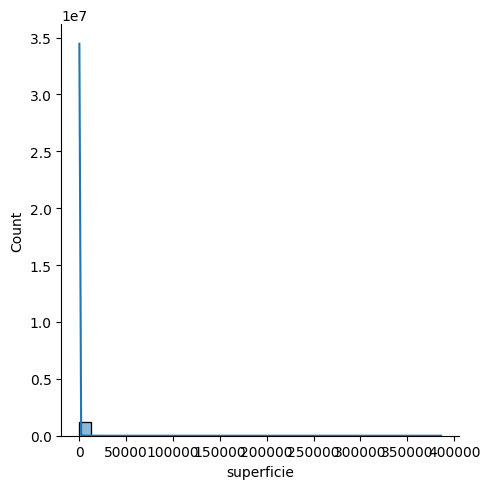

In [15]:
sns.displot(df['superficie'], bins=30, kde=True)

In [14]:
df[df['superficie'] > 100000]

,id_edificio,municipio,provincia,zona_climatica,ano_construccion,normativa,tipo_edificio,superficie,compacidad,pct_calefactado,pct_refrigerado,ventana_norte,ventana_sur,ventana_este,ventana_oeste,tipo_generador_cal,consumo_global
147469,147469,La Línea de la Concepción,Cádiz,A3,1974.0,Anterior,LocalUsoTerciario,127481.00,290.24,0,0,5.0,8.0,0.0,0.0,NaN,11.88
154107,154107,Conil de la Frontera,Cádiz,A3,1998.0,NBE-CT-79,EdificioUsoTerciario,201014.70,3.65,100,99,12.0,15.0,1.0,16.0,Bomba de Calor,93.46
299152,299152,Córdoba,Córdoba,B4,1994.0,NBE-CT-79,EdificioUsoTerciario,110686.00,2.31,100,100,3.0,22.0,0.0,0.0,Bomba de Calor,132.39
299186,299186,Córdoba,Córdoba,B4,1994.0,NBE-CT-79,EdificioUsoTerciario,110686.00,2.31,100,100,3.0,22.0,0.0,0.0,Bomba de Calor,132.39
351332,351332,Granada,Granada,C3,1940.0,NBE-CT-79,EdificioUsoTerciario,386049.59,11.11,15,15,15.0,8.0,2.0,1.0,Expansión directa aire-aire bomba de calor,153.25
352306,352306,Granada,Granada,C3,1979.0,NBE-CT-79,EdificioUsoTerciario,386049.59,11.11,15,15,15.0,8.0,2.0,1.0,Expansión directa aire-aire bomba de calor,153.25
653646,653646,Málaga,Málaga,A3,1991.0,NBE-CT-79,EdificioUsoTerciario,150908.00,6.85,100,100,130.0,115.0,0.0,0.0,Bomba de Calor,196.67
709460,709460,Málaga,Málaga,A3,NaN,CTE HE 2019,EdificioUsoTerciario,152769.05,5.79,100,100,13.0,88.0,20.0,28.0,Eléctrica,89.49
830725,830725,Casares,Málaga,C3,2005.0,NBE-CT-79,ViviendaUnifamiliar,119075.00,889.36,100,0,23.0,25.0,21.0,7.0,Caldera Condensación,2.32
1028153,1028153,Dos Hermanas,Sevilla,B4,2013.0,CTE HE 2013,BloqueDeViviendaCompleto,110833.29,7.23,100,100,16.0,13.0,0.0,0.0,Expansión directa aire-aire bomba de calor,28.40


In [15]:
df.tipo_edificio.value_counts()

tipo_edificio
ViviendaIndividualEnBloque    588062
ViviendaUnifamiliar           465646
BloqueDeViviendaCompleto       70943
LocalUsoTerciario              56668
EdificioUsoTerciario           17702
Name: count, dtype: int64

Vemos que tenemos dos poblaciones diferenciadas...vamos a centrar nuestros modelos únicamente en viviendas para evitar que estos gigantes comerciales  empañen nuestro modelo.

In [16]:
df = df.loc[~df['tipo_edificio'].isin(['EdificioUsoTerciario', 'LocalUsoTerciario']), :]
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1124652 entries, 0 to 1199020
Data columns (total 17 columns):
 #   Column              Non-Null Count    Dtype   
---  ------              --------------    -----   
 0   id_edificio         1124652 non-null  int64   
 1   municipio           1124530 non-null  category
 2   provincia           1124646 non-null  category
 3   zona_climatica      1124651 non-null  category
 4   ano_construccion    1118203 non-null  float64 
 5   normativa           1121326 non-null  category
 6   tipo_edificio       1124651 non-null  category
 7   superficie          1124652 non-null  float64 
 8   compacidad          1124652 non-null  float64 
 9   pct_calefactado     1124652 non-null  int64   
 10  pct_refrigerado     1124652 non-null  int64   
 11  ventana_norte       1124652 non-null  float64 
 12  ventana_sur         1124652 non-null  float64 
 13  ventana_este        1124652 non-null  float64 
 14  ventana_oeste       1124652 non-null  float64 
 15  tip

In [17]:
df[df['superficie'] < 30]

,id_edificio,municipio,provincia,zona_climatica,ano_construccion,normativa,tipo_edificio,superficie,compacidad,pct_calefactado,pct_refrigerado,ventana_norte,ventana_sur,ventana_este,ventana_oeste,tipo_generador_cal,consumo_global
2403,2403,Roquetas de mar,Almería,A4,1975.0,Anterior,ViviendaIndividualEnBloque,29.00,2.86,0,0,4.0,45.0,0.0,0.0,NaN,282.09
3052,3052,Roquetas de Mar,Almería,A4,1970.0,Anterior,ViviendaIndividualEnBloque,19.50,2.96,0,0,31.0,71.0,0.0,0.0,NaN,194.29
3053,3053,Roquetas de Mar,Almería,A4,1970.0,Anterior,ViviendaIndividualEnBloque,19.50,2.96,0,0,31.0,71.0,0.0,0.0,NaN,194.29
3054,3054,Roquetas de Mar,Almería,A4,1970.0,Anterior,ViviendaIndividualEnBloque,25.00,3.00,0,0,31.0,65.0,0.0,0.0,NaN,178.19
3220,3220,VICAR,Almería,A4,2003.0,NBE-CT-79,ViviendaIndividualEnBloque,20.22,1.68,0,0,34.0,0.0,0.0,0.0,NaN,281.58
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1197948,1197948,Sevilla,Sevilla,B4,1974.0,Anterior,ViviendaIndividualEnBloque,26.39,7.85,100,100,0.0,33.0,0.0,0.0,Bomba de Calor - Caudal Ref. Variable,118.81
1198597,1198597,Utrera,Sevilla,B4,2009.0,Anterior,ViviendaIndividualEnBloque,29.00,1.23,0,0,53.0,0.0,0.0,0.0,NaN,271.97
1198781,1198781,MARCHENA,Sevilla,B4,1995.0,Anterior,ViviendaIndividualEnBloque,27.21,1.67,44,44,34.0,0.0,12.0,0.0,Bomba de Calor,196.51
1198959,1198959,Sevilla,Sevilla,B4,1973.0,Anterior,ViviendaIndividualEnBloque,29.75,1.16,0,0,26.0,8.0,0.0,0.0,NaN,226.48


Vamos a entender que no hay viviendas tan pequeñas. Podemos pasar los registros a missing o eliminarlos. En este caso, vamos a eliminarlos, ya que hemos calculado el consumo por m2, y estos registros podrían afectar al modelo. Además, no son muchos registros, por lo que no perderemos mucha información.

In [18]:
df = df.loc[df['superficie'] > 30, :]

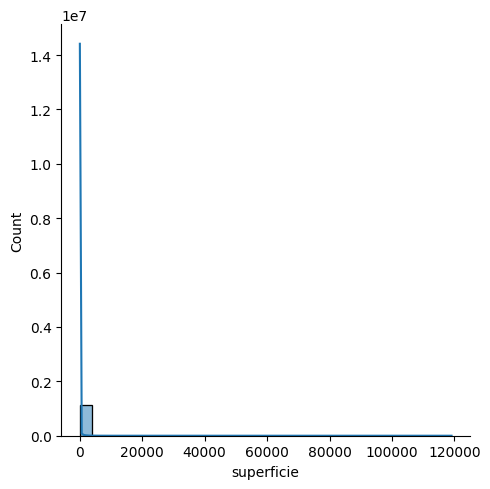

In [18]:
sns.displot(df['superficie'], bins=30, kde=True)

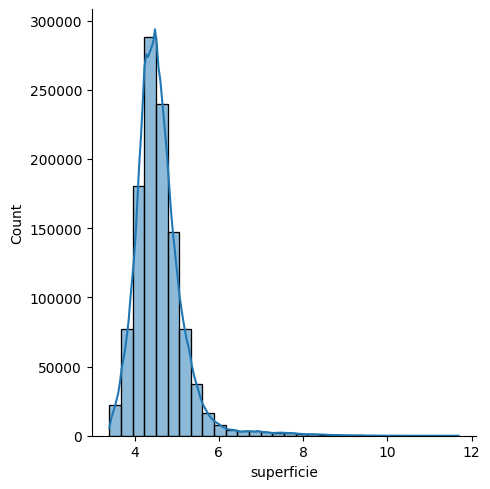

In [19]:
sns.displot(np.log(df['superficie']), bins=30, kde=True)

In [19]:
# Vamos a transformar a logarítmica, ya que la distribución es muy asimétrica, y esto podría afectar al modelo.
# Se mantiene la forma de la distribución, pero se reduce la asimetría.

df['log_superficie'] = np.log(df['superficie'])
df.drop(columns=['superficie'], inplace=True)

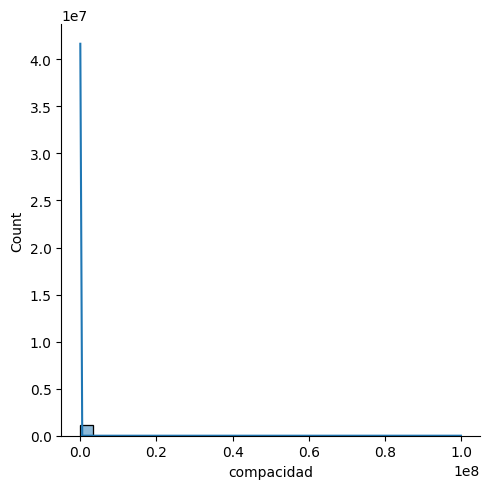

In [22]:
sns.displot(df['compacidad'], bins=30, kde=True)

In [20]:
df[df['compacidad'] < 0.5]

,id_edificio,municipio,provincia,zona_climatica,ano_construccion,normativa,tipo_edificio,compacidad,pct_calefactado,pct_refrigerado,ventana_norte,ventana_sur,ventana_este,ventana_oeste,tipo_generador_cal,consumo_global,log_superficie
670,670,Almería,Almería,A4,1965.0,Anterior,BloqueDeViviendaCompleto,0.48,0,22,24.0,33.0,0.0,0.0,NaN,299.35,3.860730
3110,3110,ZURGENA,Almería,A4,2005.0,NBE-CT-79,ViviendaUnifamiliar,0.47,97,97,9.0,15.0,27.0,0.0,Bomba de Calor,256.85,4.127134
3876,3876,Almería,Almería,A4,2004.0,NBE-CT-79,BloqueDeViviendaCompleto,0.46,70,70,30.0,24.0,0.0,0.0,Bomba de Calor - Caudal Ref. Variable,193.15,4.051785
5218,5218,HUERCAL DE ALMERÍA,Almería,A4,2010.0,C.T.E.,ViviendaIndividualEnBloque,0.46,100,100,4.0,12.0,0.0,0.0,Bomba de Calor,206.23,5.221166
6123,6123,TABERNAS,Almería,A4,2011.0,C.T.E.,ViviendaUnifamiliar,0.46,100,100,0.0,4.0,11.0,5.0,Bomba de Calor,125.36,4.605170
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1189392,1189392,Mairena del Aljarafe,Sevilla,B4,1984.0,NBE-CT-79,ViviendaUnifamiliar,0.35,100,100,3.0,3.0,35.0,12.0,Bomba de Calor,298.46,4.605170
1190910,1190910,Sevilla,Sevilla,B4,1967.0,Anterior,ViviendaIndividualEnBloque,0.47,18,18,0.0,0.0,9.0,36.0,Bomba de Calor,197.99,4.189655
1193951,1193951,GUILLENA,Sevilla,B4,1985.0,NBE-CT-79,ViviendaIndividualEnBloque,0.47,76,76,8.0,12.0,0.0,4.0,Bomba de Calor,429.95,4.276666
1198487,1198487,Alcalá de Guadaira,Sevilla,B4,1920.0,Anterior,ViviendaUnifamiliar,0.34,0,0,8.0,0.0,35.0,80.0,NaN,277.87,4.066459


In [21]:
df[df['compacidad'] > 100]

,id_edificio,municipio,provincia,zona_climatica,ano_construccion,normativa,tipo_edificio,compacidad,pct_calefactado,pct_refrigerado,ventana_norte,ventana_sur,ventana_este,ventana_oeste,tipo_generador_cal,consumo_global,log_superficie
17956,17956,LAUJAR DE ANDARAX,Almería,A4,1970.0,Anterior,ViviendaUnifamiliar,188.67,5,0,10.0,112.0,0.0,0.0,Caldera Estándar,29.97,6.338594
20334,20334,ZURGENA,Almería,A4,1979.0,Anterior,ViviendaUnifamiliar,177.67,96,94,10.0,112.0,0.0,0.0,Caldera Estándar,52.06,6.278521
21897,21897,ALHABIA,Almería,A4,1980.0,Anterior,ViviendaUnifamiliar,383.44,61,60,10.0,112.0,0.0,0.0,Caldera Estándar,70.47,7.690286
26052,26052,Almería,Almería,A4,1998.0,NBE-CT-79,ViviendaUnifamiliar,100.33,10,0,10.0,112.0,0.0,0.0,Caldera Estándar,59.63,5.707110
35507,35507,El Ejido,Almería,A4,2008.0,C.T.E.,BloqueDeViviendaCompleto,200.52,0,0,31.0,0.0,0.0,8.0,NaN,7.37,8.820109
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1164800,1164800,Sevilla,Sevilla,B4,1900.0,NaN,ViviendaIndividualEnBloque,104.00,100,100,0.0,5.0,0.0,0.0,Sistema de rendimiento estacional constante,22.94,6.590301
1165307,1165307,Sevilla,Sevilla,B4,1900.0,NaN,ViviendaIndividualEnBloque,104.00,100,100,0.0,5.0,0.0,0.0,Sistema de rendimiento estacional constante,22.94,6.590301
1168828,1168828,Sevilla,Sevilla,B4,1996.0,NBE-CT-79,BloqueDeViviendaCompleto,99999999.99,0,0,0.0,0.0,0.0,0.0,NaN,50.48,4.204693
1172028,1172028,Dos Hermanas,Sevilla,B4,1991.0,NBE-CT-79,ViviendaUnifamiliar,99999999.99,100,100,0.0,0.0,0.0,0.0,Bomba de Calor,15.99,5.056246


In [22]:
# lo mas probable es que estos registros sean errores de medición. Vamos a eliminarlos, ya que podrían afectar al modelo, y no son muchos registros, por lo que no perderemos mucha información.


In [23]:
df = df.loc[(df['compacidad'] > 0.5) & (df['compacidad'] < 100), :]

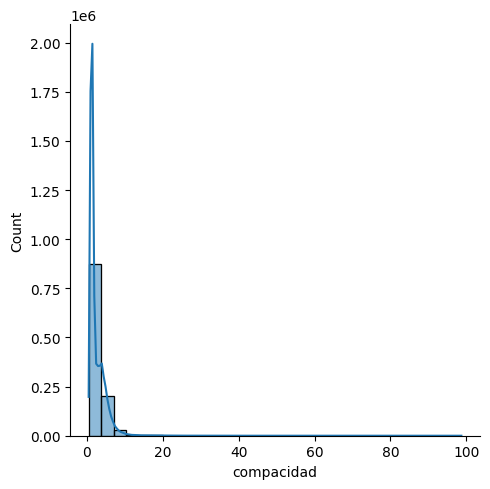

In [24]:
sns.displot(df['compacidad'], bins=30, kde=True)

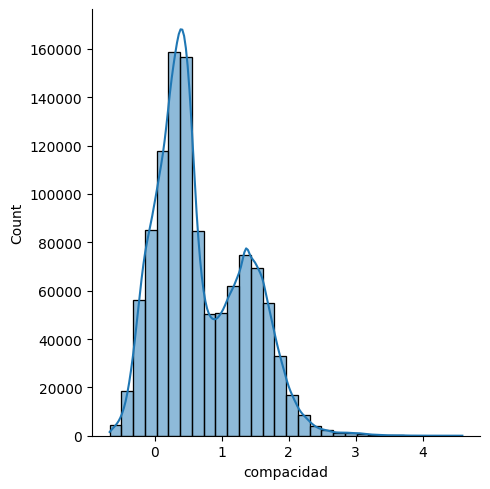

In [25]:
sns.displot(np.log(df['compacidad']), bins=30, kde=True)

In [24]:
# Vamos a transformar a logarítmica, ya que la distribución es muy asimétrica, y esto podría afectar al modelo.
# Se mantiene la forma de la distribución, pero se reduce la asimetría.

df['log_compacidad'] = np.log(df['compacidad'])
df.drop(columns=['compacidad'], inplace=True)

Vamos a revisar la target, que en el describe teníamos valores infinitos (sería por las divisiones donde teníamos superficies pequeñas, deberían haber desaparecido)

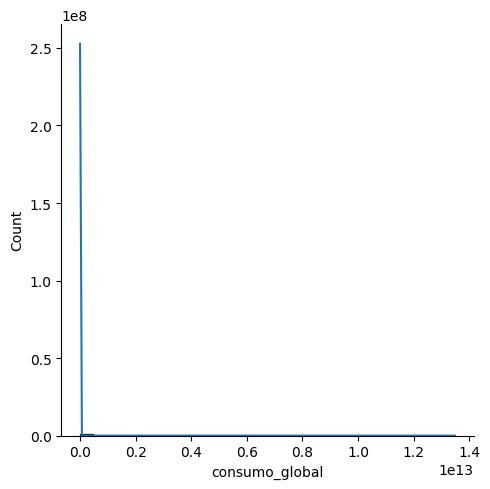

In [27]:
sns.displot(df['consumo_global'], bins=30, kde=True)

In [25]:
df[df['consumo_global'] > 1000]

,id_edificio,municipio,provincia,zona_climatica,ano_construccion,normativa,tipo_edificio,pct_calefactado,pct_refrigerado,ventana_norte,ventana_sur,ventana_este,ventana_oeste,tipo_generador_cal,consumo_global,log_superficie,log_compacidad
91104,91104,Almería,Almería,A4,1967.0,Anterior,ViviendaIndividualEnBloque,19,19,99.0,51.0,0.0,0.0,Bomba de Calor - Caudal Ref. Variable,1.187170e+03,4.060443,0.412110
113134,113134,Almería,Almería,A4,1925.0,Anterior,ViviendaUnifamiliar,0,0,0.0,0.0,21.0,22.0,NaN,1.077620e+03,4.039536,-0.127833
233451,233451,El Puerto de Santa María,Cádiz,A3,1963.0,Anterior,ViviendaIndividualEnBloque,0,0,16.0,13.0,0.0,0.0,NaN,1.016910e+03,3.706719,1.111858
270075,270075,Luque,Córdoba,D3,1960.0,NaN,ViviendaUnifamiliar,100,100,36.0,17.0,0.0,0.0,Calefacción eléctrica unizona,1.606454e+10,5.145458,0.542324
284031,284031,Córdoba,Córdoba,B4,1979.0,NBE-CT-79,ViviendaIndividualEnBloque,100,100,0.0,0.0,21.0,20.0,Sistema de rendimiento estacional constante,3.187200e+03,4.672829,2.124654
284927,284927,Santaella,Córdoba,B3,1989.0,NBE-CT-79,BloqueDeViviendaCompleto,19,19,14.0,23.0,0.0,0.0,Bomba de Calor,1.136540e+03,4.759692,1.481605
286162,286162,Priego de Córdoba,Córdoba,D3,1988.0,NBE-CT-79,ViviendaIndividualEnBloque,0,0,18.0,22.0,0.0,0.0,NaN,2.501740e+03,4.093344,1.018847
290219,290219,Espiel,Córdoba,D3,1960.0,Normativa aplicable en el año constructivo,ViviendaUnifamiliar,60,60,18.0,0.0,11.0,0.0,Otros sistemas eléctricos,1.082630e+03,4.094345,-0.248461
303661,303661,Córdoba,Córdoba,B4,1970.0,Anterior,ViviendaIndividualEnBloque,75,75,41.0,0.0,0.0,0.0,Bomba de Calor,3.574360e+03,5.611923,0.215111
314467,314467,VILLANUEVA DE CORDOBA,Córdoba,D3,1979.0,NBE-CT-79,ViviendaUnifamiliar,100,100,27.0,32.0,11.0,0.0,Unidad exterior en expansión directa,8.598450e+09,4.662401,0.262364


In [26]:
df = df.loc[(df['consumo_global'] > 0) & (df['consumo_global'] < 1000), :]

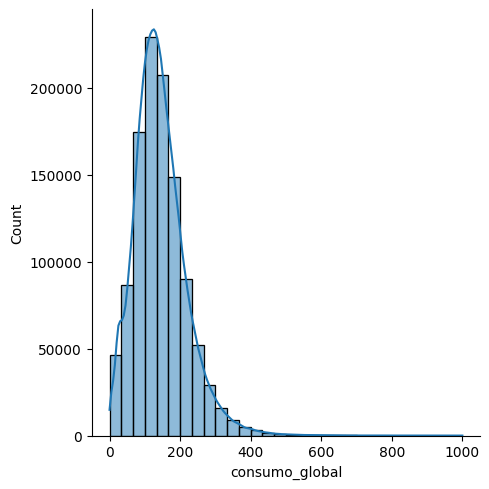

In [30]:
sns.displot(df['consumo_global'], bins=30, kde=True)

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1100693 entries, 0 to 1199020
Data columns (total 17 columns):
 #   Column              Non-Null Count    Dtype   
---  ------              --------------    -----   
 0   id_edificio         1100693 non-null  int64   
 1   municipio           1100573 non-null  category
 2   provincia           1100687 non-null  category
 3   zona_climatica      1100692 non-null  category
 4   ano_construccion    1094402 non-null  float64 
 5   normativa           1097435 non-null  category
 6   tipo_edificio       1100692 non-null  category
 7   pct_calefactado     1100693 non-null  int64   
 8   pct_refrigerado     1100693 non-null  int64   
 9   ventana_norte       1100693 non-null  float64 
 10  ventana_sur         1100693 non-null  float64 
 11  ventana_este        1100693 non-null  float64 
 12  ventana_oeste       1100693 non-null  float64 
 13  tipo_generador_cal  700195 non-null   category
 14  consumo_global      1100693 non-null  float64 
 15  log

In [28]:
#report = ProfileReport(df, title='EDA_Report', explorative=True)
#report.to_file('../reports/eda_report.html')

## 4. Categóricas - Correcciones cardinalidad, balance, etc...

In [29]:
df.select_dtypes(include=['category']).describe().round(2).T

,count,unique,top,freq
municipio,1100573,12548,Sevilla,82283
provincia,1100687,109,Málaga,282219
zona_climatica,1100692,14,A3,320647
normativa,1097435,1962,NBE-CT-79,545698
tipo_edificio,1100692,3,ViviendaIndividualEnBloque,577940
tipo_generador_cal,700195,85,Bomba de Calor,414676


Con respecto a las geográficas...tenemos demasiada cardinalidad. Probablemente nos deshagamos del código postal o el municipio, y a ver si podemos agrupar el resto.

In [30]:
df.provincia.value_counts()

provincia
Málaga                  282219
Sevilla                 241099
Cádiz                   141488
Granada                 138579
Almería                 107454
                         ...  
C/CARTAGENA 103,3ºIZ         0
Castellón                    0
CÓRODOBA                     0
Zaragoza                     0
ALMUÑECAR                    0
Name: count, Length: 117, dtype: int64

In [31]:
df.provincia = df.provincia.cat.remove_unused_categories()

In [32]:
df.provincia.value_counts().tail(25)

provincia
AlmerÃ­a      1
ALMERIMA      1
A Coru�a      1
Provincia     1
Navarra       1
Cádiz\n       1
Jaén.         1
Huelva-       1
LEPE          1
Huelva        1
Linares       1
Lleida        1
-             1
Guipúzcoa     1
GRANDA        1
GRANADA.      1
Melilla       1
FUENGIROLA    1
MÃ¡laga       1
Málaga        1
Málga         1
Mďż˝laga      1
Cádiz -       1
M��laga       1
(Sevilla)     1
Name: count, dtype: int64

In [33]:
df.provincia.value_counts(normalize=True).head(8).sum()

0.9969846105205202

Tenemos prácticamente todo el dataset en las 8 provincias, vamos a limpiarlo

In [34]:
provincias = list(df.provincia.value_counts().head(8).index)
provincias

['Málaga',
 'Sevilla',
 'Cádiz',
 'Granada',
 'Almería',
 'Córdoba',
 'Jaén',
 'Huelva']

In [35]:
df = df.loc[df['provincia'].isin(provincias), :]

In [36]:
df.provincia = df.provincia.cat.remove_unused_categories()
df.provincia.value_counts()

provincia
Málaga     282219
Sevilla    241099
Cádiz      141488
Granada    138579
Almería    107454
Córdoba     68426
Jaén        60798
Huelva      57305
Name: count, dtype: int64

In [37]:
df.municipio = df.municipio.cat.remove_unused_categories()
df.municipio.value_counts()


municipio
Sevilla                              82282
Málaga                               54659
Granada                              33963
Marbella                             33208
Córdoba                              31097
                                     ...  
HAZA GALERAS (ARCHIDONA)                 1
Güi (Torrox)                             1
Güevéjar (866 msnm)                      1
Güevejar                                 1
Jerez de la Frontera (Cuartillos)        1
Name: count, Length: 12399, dtype: int64

In [38]:
df.municipio.value_counts(normalize=True).head(500).sum()

0.8851842873208938

In [39]:
municipios = list(df.municipio.value_counts().tail(500).index)
municipios

['ESTEPNA',
 'ESTELLA DEL MARQUÉS',
 'ESTELLA DEL MARQUEZ',
 'ESTELLA DEL MARQUES (JEREZ DE LA FRA)',
 'ESTACIÓN LINARES BAEZA',
 'ESTACIÓN GAUCÍN',
 'ESQUIVEL - ALCALÁ DEL RÍO',
 'ESTACIÓN FERREA DE SAN ROQUE',
 'ESTACIÓN DE SALINAS',
 'ESTACIÓN DE GAUCÍN-C.FTRA',
 'ESTACIÓN DE GAUCÍN',
 'ESTACION LINARES-BAEZA / LINARES',
 'ESTACION DE CARTAMA. CARTAMA',
 'ESTACION DE BOBADILLA',
 'ESTACION DE ARCHIDONA',
 'EST.GAUCÍN-EL COLMENAR',
 'EST.GAUCÍN-CORTES FTRA',
 'EST.DE GAUCÍN-CORTES FTRA',
 'ESSTEPONA',
 'Fuente del Conde (Iznájar)',
 'Fuente la Lancha',
 'LA MOLINA (COLMENAR)',
 'JABUEGO',
 'JEREZ DE LA FRA',
 'JEGEN, ALPUJARRA DE LA SIERRA',
 'JEDULA_ARCOS FRA',
 'JEDULA (ARCOS DE LA FRA.)',
 'JAUCA',
 'JAU - SANTA FE',
 'JAU (SANTA FE)',
 'JAEMILENA',
 'JABUGUILLO_ARACENA',
 'JABUGUILLO, TM ARACENA',
 'JABUGUILLO (ARACENA)',
 'JABUGO, REPILADO',
 'Iznajar - Fuente del Conde',
 'JEREZ FRA. (NUEVA JARILLA)',
 'Izbor- El Pinar',
 'Itrabo ',
 'Istan ',
 'Islatilla',
 'Islantilla - Isla 

In [40]:
df[df['municipio'].isin(municipios)].municipio.value_counts(normalize=True).head(300).map('{:.4f}'.format)

municipio
Jerez de la Frontera (Cuartillos)    0.0020
HUElva                               0.0020
Hinojosa                             0.0020
Hijas (Las Gabias)                   0.0020
Hijar, Las Gabías                    0.0020
                                      ...  
GUILLENA/TORRE DE LA REINA           0.0020
GUILLENA. LAS PAJANOSAS              0.0020
GUILLENA [SEVILLA]                   0.0020
GUILLENA - LAS PAJANOSAS             0.0020
GUILLENA (TORRELAREINA)              0.0020
Name: proportion, Length: 300, dtype: object

Es una locura tanta cardinalidad...No vamos a contar con esta variable para los primeros modelos. más adelante vemos si la recuperamos.

In [41]:
df.drop(columns=['municipio'], inplace=True)

In [42]:
df.select_dtypes(include=['category']).describe().round(2).T

,count,unique,top,freq
provincia,1097368,8,Málaga,282219
zona_climatica,1097368,13,A3,319754
normativa,1094119,1738,NBE-CT-79,545324
tipo_edificio,1097368,3,ViviendaIndividualEnBloque,577503
tipo_generador_cal,697241,81,Bomba de Calor,414585


In [43]:
df.zona_climatica.value_counts()

zona_climatica
A3             319754
B4             301597
A4             167787
C3             144686
C4              74380
B3              46512
D3              35668
C1               3687
D2               1082
E1               1052
C2                845
D1                317
c4                  1
-- Todas --         0
Name: count, dtype: int64

Vamos a separar la letra y el número según el cte

In [44]:
df.zona_climatica = df.zona_climatica.str.upper().str.strip()

In [45]:
df['zona_clima_invierno'] = df.zona_climatica.apply(lambda x: x[0] if pd.notnull(x) else x)
df['zona_clima_verano'] = df.zona_climatica.apply(lambda x: x[1] if pd.notnull(x) else x)

In [46]:
df.zona_clima_invierno.value_counts()

zona_clima_invierno
A    487541
B    348109
C    223599
D     37067
E      1052
Name: count, dtype: int64

In [47]:
df.zona_clima_verano.value_counts()

zona_clima_verano
3    546620
4    543765
1      5056
2      1927
Name: count, dtype: int64

<Axes: xlabel='zona_clima_invierno', ylabel='consumo_global'>

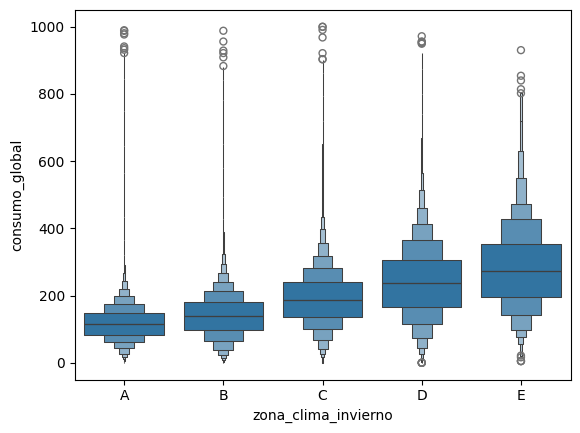

In [48]:
# Revisamos la relación con la v.objetivo para ver si podemos agrupar

sns.boxenplot(
    df,
    x='zona_clima_invierno',
    y='consumo_global'
)

<Axes: xlabel='zona_clima_verano', ylabel='consumo_global'>

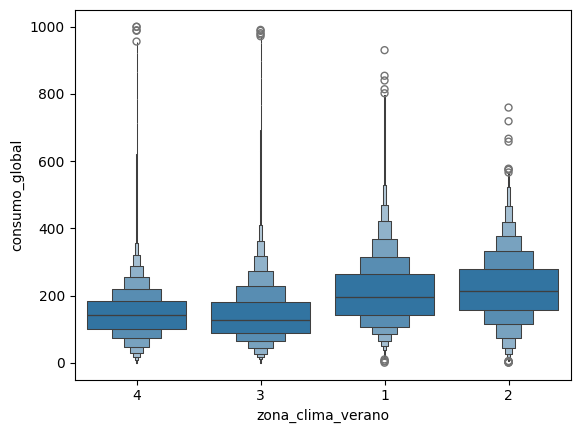

In [49]:
sns.boxenplot(
    df,
    x='zona_clima_verano',
    y='consumo_global'
)

In [50]:
df.zona_clima_invierno.value_counts(normalize=True)

zona_clima_invierno
A    0.444282
B    0.317222
C    0.203759
D    0.033778
E    0.000959
Name: proportion, dtype: float64

In [51]:
df.zona_clima_verano.value_counts(normalize=True)

zona_clima_verano
3    0.498119
4    0.495517
1    0.004607
2    0.001756
Name: proportion, dtype: float64

In [52]:
df['zona_clima_invierno'] = df['zona_clima_invierno'].replace({'E': 'Otros'})
df['zona_clima_invierno'] = df['zona_clima_invierno'].replace({'D': 'Otros'})


In [53]:
df = df.loc[~df['zona_clima_verano'].isin(['1', '2']), :]
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1090385 entries, 0 to 1199020
Data columns (total 18 columns):
 #   Column               Non-Null Count    Dtype   
---  ------               --------------    -----   
 0   id_edificio          1090385 non-null  int64   
 1   provincia            1090385 non-null  category
 2   zona_climatica       1090385 non-null  object  
 3   ano_construccion     1084354 non-null  float64 
 4   normativa            1087180 non-null  category
 5   tipo_edificio        1090385 non-null  category
 6   pct_calefactado      1090385 non-null  int64   
 7   pct_refrigerado      1090385 non-null  int64   
 8   ventana_norte        1090385 non-null  float64 
 9   ventana_sur          1090385 non-null  float64 
 10  ventana_este         1090385 non-null  float64 
 11  ventana_oeste        1090385 non-null  float64 
 12  tipo_generador_cal   693775 non-null   category
 13  consumo_global       1090385 non-null  float64 
 14  log_superficie       1090385 non-null  

In [54]:
df.zona_clima_verano.value_counts(normalize=True)

zona_clima_verano
3    0.501309
4    0.498691
Name: proportion, dtype: float64

In [55]:
df.zona_clima_invierno.value_counts(normalize=True)

zona_clima_invierno
A        0.447127
B        0.319253
C        0.200908
Otros    0.032711
Name: proportion, dtype: float64

In [56]:
df.zona_climatica.value_counts(normalize=True)

zona_climatica
A3    0.293249
B4    0.276597
A4    0.153879
C3    0.132693
C4    0.068215
B3    0.042656
D3    0.032711
Name: proportion, dtype: float64

In [57]:
df.select_dtypes(exclude=np.number).describe().round(2).T

,count,unique,top,freq
provincia,1090385,8,Málaga,279143
zona_climatica,1090385,7,A3,319754
normativa,1087180,1732,NBE-CT-79,541727
tipo_edificio,1090385,3,ViviendaIndividualEnBloque,574620
tipo_generador_cal,693775,81,Bomba de Calor,413477
zona_clima_invierno,1090385,4,A,487541
zona_clima_verano,1090385,2,3,546620


In [58]:
df.tipo_edificio.value_counts()

tipo_edificio
ViviendaIndividualEnBloque    574620
ViviendaUnifamiliar           447271
BloqueDeViviendaCompleto       68494
EdificioUsoTerciario               0
LocalUsoTerciario                  0
Name: count, dtype: int64

In [59]:
df.tipo_edificio = df.tipo_edificio.cat.remove_unused_categories()

In [60]:
df.tipo_edificio.value_counts(normalize=True)

tipo_edificio
ViviendaIndividualEnBloque    0.526988
ViviendaUnifamiliar           0.410195
BloqueDeViviendaCompleto      0.062816
Name: proportion, dtype: float64

In [61]:
df.normativa.value_counts()

normativa
NBE-CT-79                541727
Anterior                 339405
C.T.E.                   122870
CTE 2013                  35312
CTE HE 2013               11273
                          ...  
CTE (REHABILITACION)          0
CTE  2019                     0
CTE  2013                     0
CT 88                         0
   anterior NBE CT-79         0
Name: count, Length: 2148, dtype: int64

In [62]:
df.normativa.value_counts(normalize=True).head(3).sum()

0.9234919700509575

In [63]:
top_normativas = ['NBE-CT-79', 'Anterior', 'C.T.E.']

In [64]:
df['normativa'] = df['normativa'].apply(lambda x: x if x in top_normativas else 'Otros')

In [65]:
df.normativa.value_counts()

normativa
NBE-CT-79    541727
Anterior     339405
C.T.E.       122870
Otros         83178
Name: count, dtype: int64

In [66]:
df.normativa.value_counts(normalize=True)

normativa
NBE-CT-79    0.498286
Anterior     0.312188
C.T.E.       0.113017
Otros        0.076508
Name: proportion, dtype: float64

In [67]:
df.select_dtypes(exclude=np.number).describe().round(2).T

,count,unique,top,freq
provincia,1090385,8,Málaga,279143
zona_climatica,1090385,7,A3,319754
normativa,1087180,4,NBE-CT-79,541727
tipo_edificio,1090385,3,ViviendaIndividualEnBloque,574620
tipo_generador_cal,693775,81,Bomba de Calor,413477
zona_clima_invierno,1090385,4,A,487541
zona_clima_verano,1090385,2,3,546620


In [68]:
df.tipo_generador_cal.value_counts().head(10)

tipo_generador_cal
Bomba de Calor                                 413477
Bomba de Calor - Caudal Ref. Variable           93806
Caldera Estándar                                75486
Sistema de rendimiento estacional constante     32485
Efecto Joule                                    24084
Bomba de calor tipo split/multisplit            16585
Expansión directa aire-aire bomba de calor       6851
Equipo de Rendimiento Constante                  6003
Bomba de calor por conductos de aire             4642
Caldera Condensación                             3060
Name: count, dtype: int64

In [69]:
# 1. Limpieza profunda: pasamos a minúsculas, quitamos espacios extra y caracteres raros
df['tipo_limpio'] = df['tipo_generador_cal'].astype(str).str.lower().str.strip()

# 2. Definimos condiciones con palabras clave muy directas
condiciones = [
    df['tipo_limpio'].str.contains(r'bomba|aire-aire|split|aerotermia', na=False),
    df['tipo_limpio'].str.contains(r'caldera', na=False),
    df['tipo_limpio'].str.contains(r'rendimiento.*constante', na=False),
    df['tipo_limpio'].str.contains(r'joule', na=False)
]

nombres = [
    'Bomba de Calor / Aerotermia',
    'Calderas',
    'Sistemas de Rendimiento Constante',
    'Efecto Joule'
]

df['tipo_agrupado'] = np.select(condiciones, nombres, default='Otros')

# 3. Verificamos el resultado
print(df['tipo_agrupado'].value_counts())

tipo_agrupado
Bomba de Calor / Aerotermia          540923
Otros                                401713
Calderas                              83866
Sistemas de Rendimiento Constante     39750
Efecto Joule                          24133
Name: count, dtype: int64


In [70]:
print(df['tipo_agrupado'].value_counts(normalize=True))

tipo_agrupado
Bomba de Calor / Aerotermia          0.496084
Otros                                0.368414
Calderas                             0.076914
Sistemas de Rendimiento Constante    0.036455
Efecto Joule                         0.022133
Name: proportion, dtype: float64


In [71]:
df = df.drop(columns=['tipo_limpio', 'tipo_generador_cal'])

In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1090385 entries, 0 to 1199020
Data columns (total 18 columns):
 #   Column               Non-Null Count    Dtype   
---  ------               --------------    -----   
 0   id_edificio          1090385 non-null  int64   
 1   provincia            1090385 non-null  category
 2   zona_climatica       1090385 non-null  object  
 3   ano_construccion     1084354 non-null  float64 
 4   normativa            1087180 non-null  object  
 5   tipo_edificio        1090385 non-null  category
 6   pct_calefactado      1090385 non-null  int64   
 7   pct_refrigerado      1090385 non-null  int64   
 8   ventana_norte        1090385 non-null  float64 
 9   ventana_sur          1090385 non-null  float64 
 10  ventana_este         1090385 non-null  float64 
 11  ventana_oeste        1090385 non-null  float64 
 12  consumo_global       1090385 non-null  float64 
 13  log_superficie       1090385 non-null  float64 
 14  log_compacidad       1090385 non-null  

In [73]:
# Antes de imputaciones o transformaciones de categóricas, vamos a guardar un csv para BI.

df.to_csv('../data/clean/df_analisis_bi.csv', index=False)

## 5. Outliers

Como ví que tenemos bastantes outliers extremos, vamos a tratarlos....probaremos modelos también después sin hacerlo

In [77]:
#Debemos separar la variable objetivo del resto de variables
varobjetivo = df['consumo_global']
imput = df.drop(columns=['consumo_global'])

In [78]:
import sys
import os

# Añadimos el directorio padre (..) al path de búsqueda
sys.path.append(os.path.abspath(os.path.join('..')))

from src.NuestrasFunciones import *

In [79]:
# Llamada en modo check
imput.select_dtypes(include=np.number).apply(lambda x: gestiona_outliers(x))#.set_index(['Low','up','Tot'])

id_edificio
ano_construccion
pct_calefactado
pct_refrigerado
ventana_norte
ventana_sur
ventana_este
ventana_oeste
log_superficie
log_compacidad


,id_edificio,ano_construccion,pct_calefactado,pct_refrigerado,ventana_norte,ventana_sur,ventana_este,ventana_oeste,log_superficie,log_compacidad
0,0.0,0.108636,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
1,0.0,0.000000,0.0,0.0,0.404719,0.863732,1.740578,2.200874,0.0,0.001284
2,0.0,0.108636,0.0,0.0,0.404719,0.863732,1.740578,2.200874,0.0,0.001284


In [80]:
impCont = imput.select_dtypes(include=np.number).copy()

imput_wins = impCont.apply(lambda x: gestiona_outliers(x,clas='winsor'))

id_edificio
ano_construccion
pct_calefactado
pct_refrigerado
ventana_norte
ventana_sur
ventana_este
ventana_oeste
log_superficie
log_compacidad


Cont


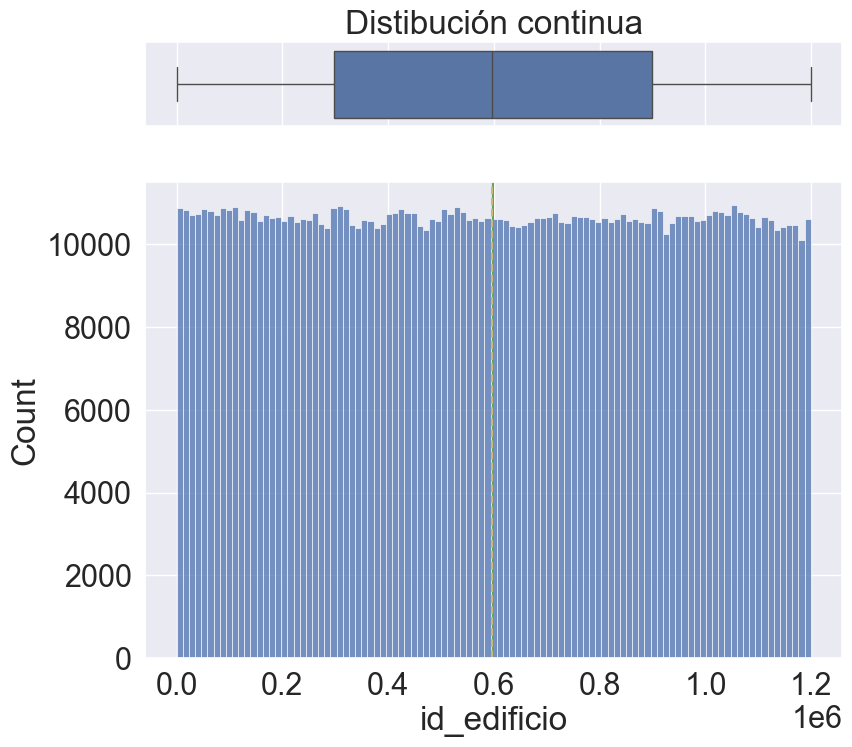

Cont


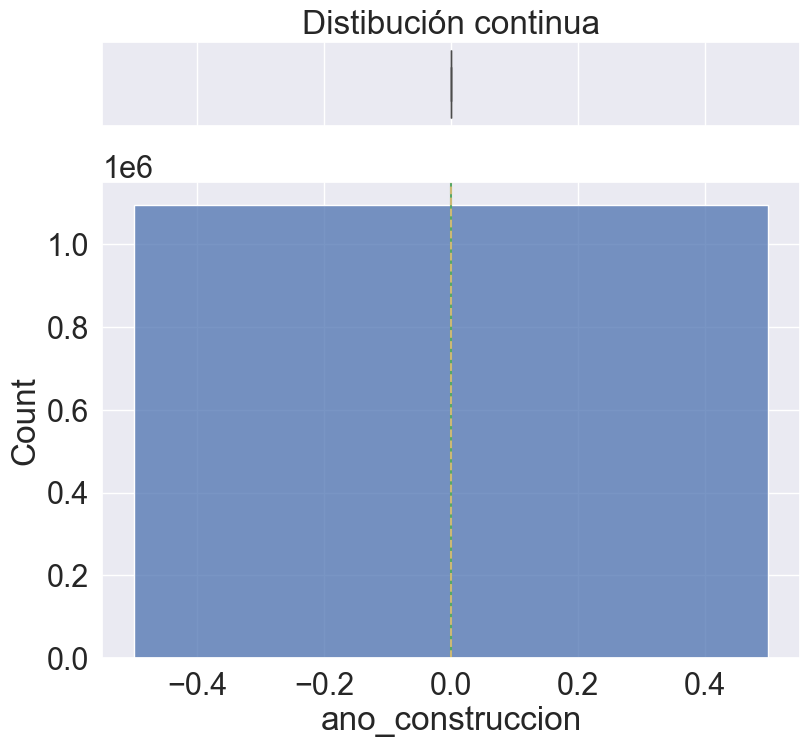

Cont


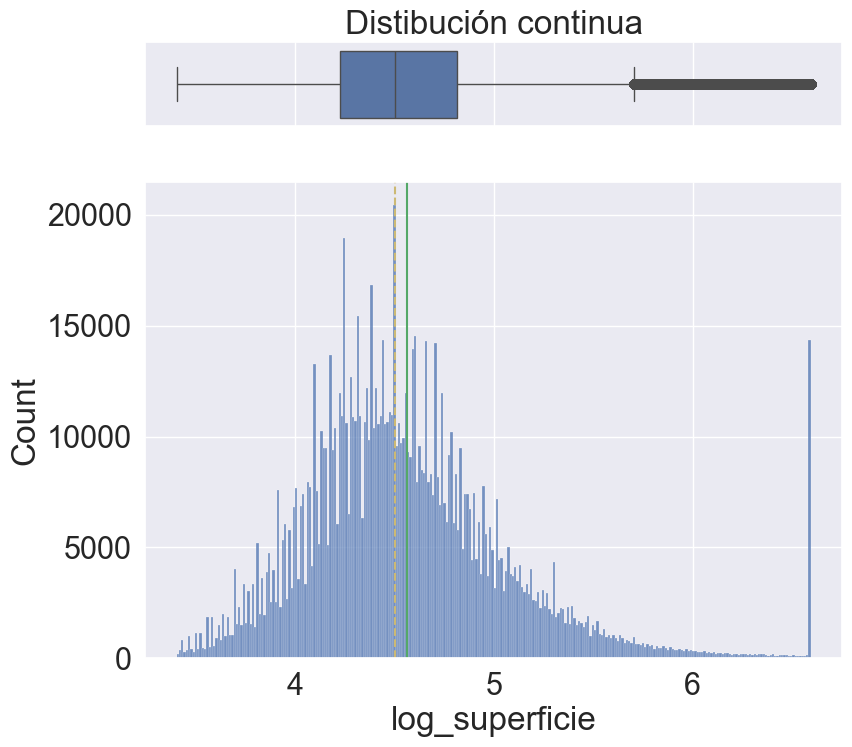

Cont


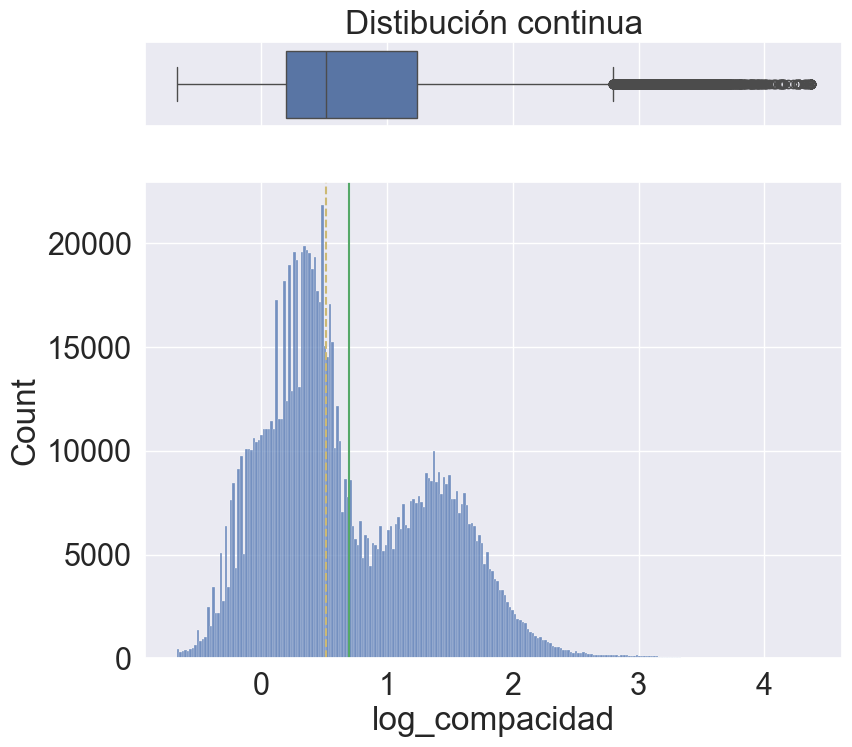

id_edificio         None
ano_construccion    None
log_superficie      None
log_compacidad      None
dtype: object

In [92]:
imput_wins.apply(plot)

## 6. Missings

In [81]:
imput_wins = pd.concat([imput_wins, imput.select_dtypes(exclude=np.number)], axis=1)

In [82]:
imput_wins.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1090385 entries, 0 to 1199020
Data columns (total 17 columns):
 #   Column               Non-Null Count    Dtype   
---  ------               --------------    -----   
 0   id_edificio          1090385 non-null  int64   
 1   ano_construccion     1084354 non-null  float64 
 2   pct_calefactado      1090385 non-null  int64   
 3   pct_refrigerado      1090385 non-null  int64   
 4   ventana_norte        1090385 non-null  float64 
 5   ventana_sur          1090385 non-null  float64 
 6   ventana_este         1090385 non-null  float64 
 7   ventana_oeste        1090385 non-null  float64 
 8   log_superficie       1090385 non-null  float64 
 9   log_compacidad       1090385 non-null  float64 
 10  provincia            1090385 non-null  category
 11  zona_climatica       1090385 non-null  object  
 12  normativa            1087180 non-null  object  
 13  tipo_edificio        1090385 non-null  category
 14  tipo_generador_cal   693775 non-null   

In [83]:
varobjetivo.info()

<class 'pandas.core.series.Series'>
Index: 1090385 entries, 0 to 1199020
Series name: consumo_global
Non-Null Count    Dtype  
--------------    -----  
1090385 non-null  float64
dtypes: float64(1)
memory usage: 16.6 MB


In [84]:
#Proporción de missings por variable
imput_wins.apply(lambda x: x.isna().sum()/imput_wins.shape[0]*100)

id_edificio             0.000000
ano_construccion        0.553107
pct_calefactado         0.000000
pct_refrigerado         0.000000
ventana_norte           0.000000
ventana_sur             0.000000
ventana_este            0.000000
ventana_oeste           0.000000
log_superficie          0.000000
log_compacidad          0.000000
provincia               0.000000
zona_climatica          0.000000
normativa               0.293933
tipo_edificio           0.000000
tipo_generador_cal     36.373391
zona_clima_invierno     0.000000
zona_clima_verano       0.000000
dtype: float64

In [100]:
#solo tenemos missings en normativa. Al ser categorica, vamos a imputar con 'desconocido', ya que es la opción más sencilla y no perderemos mucha información, ya que el porcentaje de missings es bajo.

imput_wins['normativa'] = imput_wins['normativa'].fillna('desconocido')

In [101]:
df_imputed = pd.concat([imput_wins, varobjetivo], axis=1)
df_imputed.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1096005 entries, 0 to 1199020
Data columns (total 10 columns):
 #   Column               Non-Null Count    Dtype   
---  ------               --------------    -----   
 0   id_edificio          1096005 non-null  int64   
 1   ano_construccion     1096005 non-null  float64 
 2   log_superficie       1096005 non-null  float64 
 3   log_compacidad       1096005 non-null  float64 
 4   provincia            1096005 non-null  category
 5   normativa            1096005 non-null  object  
 6   tipo_edificio        1096005 non-null  category
 7   zona_clima_invierno  1096005 non-null  object  
 8   zona_clima_verano    1096005 non-null  object  
 9   consumo_m2           1096005 non-null  float64 
dtypes: category(2), float64(4), int64(1), object(3)
memory usage: 77.3+ MB


## 8. Transformar categóricas a numéricas

In [102]:
df_imputed.select_dtypes(exclude=np.number).nunique().sort_values(ascending=False)

provincia              8
normativa              5
zona_clima_invierno    4
tipo_edificio          3
zona_clima_verano      3
dtype: int64

Vamos a hacerlas todas dummis, ya que no tenemos muchas variables categoricas, y esto nos permitirá usar modelos lineales sin necesidad de hacer transformaciones adicionales.

In [103]:
var_cat = df_imputed.select_dtypes(exclude=np.number).nunique().sort_values(ascending=False).index.tolist()

In [105]:
dummies = pd.get_dummies(df_imputed[var_cat])

In [112]:
df_dummies = pd.concat([df_imputed.drop(columns=var_cat), dummies], axis=1)
df_dummies.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1096005 entries, 0 to 1199020
Data columns (total 28 columns):
 #   Column                                    Non-Null Count    Dtype  
---  ------                                    --------------    -----  
 0   id_edificio                               1096005 non-null  int64  
 1   ano_construccion                          1096005 non-null  float64
 2   log_superficie                            1096005 non-null  float64
 3   log_compacidad                            1096005 non-null  float64
 4   consumo_m2                                1096005 non-null  float64
 5   provincia_Almería                         1096005 non-null  bool   
 6   provincia_Cádiz                           1096005 non-null  bool   
 7   provincia_Córdoba                         1096005 non-null  bool   
 8   provincia_Granada                         1096005 non-null  bool   
 9   provincia_Huelva                          1096005 non-null  bool   
 10  provincia_J

In [113]:
df_depurado =df_dummies.set_index('id_edificio')

In [114]:
df_depurado.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1096005 entries, 0 to 1199020
Data columns (total 27 columns):
 #   Column                                    Non-Null Count    Dtype  
---  ------                                    --------------    -----  
 0   ano_construccion                          1096005 non-null  float64
 1   log_superficie                            1096005 non-null  float64
 2   log_compacidad                            1096005 non-null  float64
 3   consumo_m2                                1096005 non-null  float64
 4   provincia_Almería                         1096005 non-null  bool   
 5   provincia_Cádiz                           1096005 non-null  bool   
 6   provincia_Córdoba                         1096005 non-null  bool   
 7   provincia_Granada                         1096005 non-null  bool   
 8   provincia_Huelva                          1096005 non-null  bool   
 9   provincia_Jaén                            1096005 non-null  bool   
 10  provincia_M